In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader

from scipy.spatial.distance import pdist, squareform, cdist
from scipy.stats import pearsonr

WORKDIR = "/Users/isabelmikheev/Desktop/Bioinformatics"
EIGENVEC = os.path.join(WORKDIR, "ursus_pca.eigenvec")
META_CSV = os.path.join(WORKDIR, "59-Ursus_workflow.csv")
OUTDIR = os.path.join(WORKDIR, "plots")
os.makedirs(OUTDIR, exist_ok=True)

def read_eigenvec(path: str) -> pd.DataFrame:
    """
    Reads PLINK2 eigenvec, typically whitespace-delimited and headerless:
      FID IID PC1 PC2 ...
    """
    df = pd.read_csv(path, sep=r"\s+", header=None)
    ncols = df.shape[1]
    if ncols < 4:
        raise ValueError(f"Unexpected eigenvec format (cols={ncols}).")
    df.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, ncols - 1)]
    df["IID"] = df["IID"].astype(str)
    return df


def dedupe_meta(meta: pd.DataFrame) -> pd.DataFrame:
    """
    Your workflow file has multiple rows per BioSample (different fastqs/runs).
    For mapping/clustering we want one row per BioSample.
    Requires columns: BioSample, lat, long
    """
    if "lat" not in meta.columns or "long" not in meta.columns:
        raise ValueError("Expected 'lat' and 'long' columns in metadata CSV.")

    meta = meta.dropna(subset=["lat", "long"]).copy()

    if "BioSample" in meta.columns:
        meta = meta.sort_values("BioSample")
        meta = meta.drop_duplicates(subset=["BioSample"], keep="first")
    else:
        meta = meta.drop_duplicates()

    meta = meta.rename(columns={"long": "lon"})
    return meta


def find_best_id_col(meta: pd.DataFrame, valid_ids: set) -> str:
    """
    Finds which metadata column best matches PLINK IID set.
    In your case, it's BioSample.
    """
    best_col, best_hits = None, -1
    for c in meta.columns:
        vals = meta[c].dropna().astype(str)
        hits = vals.isin(valid_ids).sum()
        if hits > best_hits:
            best_hits, best_col = hits, c
    print(f"Best ID column guess: {best_col} (matches={best_hits})")
    if best_hits <= 0:
        raise ValueError("No metadata column matches eigenvec IIDs.")
    return best_col


def relabel_by_mean_lon(df: pd.DataFrame, labels: np.ndarray) -> np.ndarray:
    """
    Make cluster numbers stable: sort clusters by mean longitude (westmost -> 0).
    """
    tmp = df.copy()
    tmp["cluster"] = labels
    order = tmp.groupby("cluster")["lon"].mean().sort_values().index.tolist()
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[x] for x in labels])



def plot_map(df, labels, title):
    fig = plt.figure(figsize=(7, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent([-125.0, -113.0, 32.0, 42.7], crs=ccrs.PlateCarree())

    shp = shapereader.natural_earth(resolution="50m", category="cultural",
                                name="admin_1_states_provinces")
    reader = shapereader.Reader(shp)

    for rec in reader.records():
    
        if rec.attributes.get("name") == "California" and rec.attributes.get("admin") == "United States of America":
            ax.add_geometries([rec.geometry], crs=ccrs.PlateCarree(), 
                              facecolor="none", edgecolor="black", linewidth=1.6)
            break

    for cl in sorted(np.unique(labels)):
        sub = df[labels == cl]
        ax.scatter(sub["lon"], sub["lat"], s=35, alpha=0.85,
                   label=f"Cluster {cl}", transform=ccrs.PlateCarree())

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_pca_scatter(df: pd.DataFrame, title: str, outpath: str):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(df["PC1"].to_numpy(), df["PC2"].to_numpy(), alpha=0.9)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
    fig.tight_layout()
    plt.show()


def plot_pca_colored(df: pd.DataFrame, labels: np.ndarray, title: str, outpath: str):
    fig, ax = plt.subplots(figsize=(7, 6))
    for cl in sorted(np.unique(labels)):
        sub = df[labels == cl]
        ax.scatter(sub["PC1"].to_numpy(), sub["PC2"].to_numpy(), alpha=0.9, label=f"Cluster {cl}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
    ax.legend()
    fig.tight_layout()
    plt.show()


def plot_two_maps(df, labels4, labels7):
    fig = plt.figure(figsize=(14, 8))
    ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
    ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())

    def add_ca_outline(ax):
        shp = shapereader.natural_earth(resolution="50m", category="cultural",
                                    name="admin_1_states_provinces")
        reader = shapereader.Reader(shp)
        for rec in reader.records():
            if rec.attributes.get("name") == "California" and rec.attributes.get("admin") == "United States of America":
                ax.add_geometries([rec.geometry], crs=ccrs.PlateCarree(), 
                                  facecolor="none", edgecolor="black", linewidth=1.6)
                break

    for ax, labels, title in [(ax1, labels4, "K=4"), (ax2, labels7, "K=7")]:
        ax.set_extent([-125.0, -113.0, 32.0, 42.7], crs=ccrs.PlateCarree())
        ax.set_aspect("auto")
        add_ca_outline(ax)

        for cl in sorted(np.unique(labels)):
            sub = df[labels == cl]
            ax.scatter(sub["lon"], sub["lat"], s=30, alpha=0.85, label=f"{cl}",
                       transform=ccrs.PlateCarree())

        tmp = df.copy()
        tmp["cluster"] = labels
        cent = tmp.groupby("cluster")[["lon", "lat"]].mean()
        for cl, row in cent.iterrows():
            ax.text(row["lon"], row["lat"], str(cl), fontsize=12, fontweight="bold",
                    ha="center", va="center", transform=ccrs.PlateCarree())

        ax.set_title(title)

    ax2.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def save_cluster_tables(df: pd.DataFrame, labels: np.ndarray, K: int):
    out = df.copy()
    out["cluster"] = labels

    summary = out.groupby("cluster").agg(
        n=("IID", "count"),
        lat_mean=("lat", "mean"),
        lon_mean=("lon", "mean"),
        lat_min=("lat", "min"),
        lat_max=("lat", "max"),
        lon_min=("lon", "min"),
        lon_max=("lon", "max"),
        PC1_mean=("PC1", "mean"),
        PC2_mean=("PC2", "mean"),
    ).reset_index()

    out.to_csv(os.path.join(OUTDIR, f"ursus_clusters_K{K}.csv"), index=False)
    summary.to_csv(os.path.join(OUTDIR, f"cluster_summary_K{K}.csv"), index=False)
    return summary


def plot_isolation_by_distance(df: pd.DataFrame, pc_cols: list, outpath: str):
    pcs = df[pc_cols].to_numpy()
    geo = df[["lat", "lon"]].to_numpy()

    genD = squareform(pdist(pcs, metric="euclidean"))
    geoD = squareform(pdist(geo, metric="euclidean"))

    iu = np.triu_indices_from(genD, k=1)
    r, p = pearsonr(genD[iu], geoD[iu])

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(geoD[iu], genD[iu], alpha=0.2)
    ax.set_xlabel("Geographic distance (lat/lon Euclidean)")
    ax.set_ylabel("Genetic distance (PC space Euclidean)")
    ax.set_title(f"Isolation by distance (r={r:.2f}, p={p:.1e})")
    fig.tight_layout()
    plt.show()

    print("Isolation-by-distance:", {"r": r, "p": p})
    return r, p


def print_nn_outliers(df: pd.DataFrame, pc_cols: list, top_n: int = 10):
    pcs = df[pc_cols].to_numpy()
    D = cdist(pcs, pcs)
    np.fill_diagonal(D, np.inf)
    nn = D.min(axis=1)

    tmp = df.copy()
    tmp["nn_PC_dist"] = nn
    print("\nTop PCA outliers by nearest-neighbor distance:")
    print(tmp.sort_values("nn_PC_dist", ascending=False).head(top_n)[["IID", "lat", "lon", "nn_PC_dist"]])


Best ID column guess: BioSample (matches=117)
Rows after merge: 117
X shape: (117, 4) PCs used: ['PC1', 'PC2', 'PC3', 'PC4']


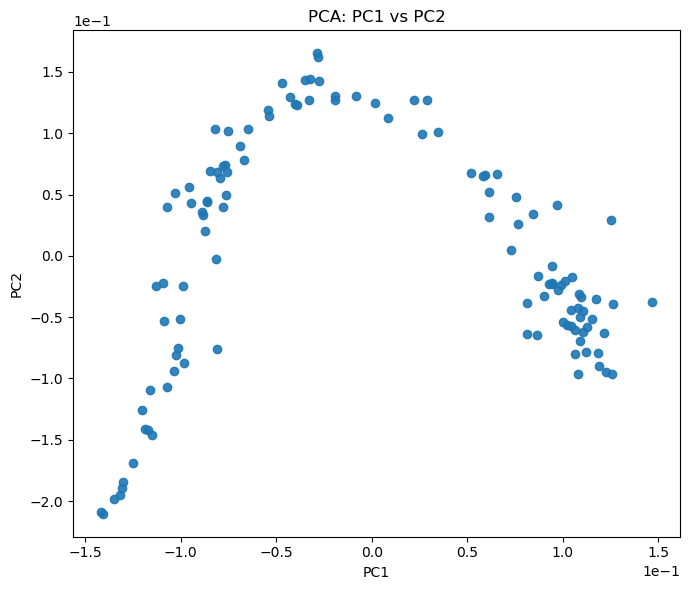

In [ ]:
pca = read_eigenvec(EIGENVEC)
meta_raw = pd.read_csv(META_CSV)
meta = dedupe_meta(meta_raw)

valid_ids = set(pca["IID"].astype(str))
id_col = find_best_id_col(meta, valid_ids) 
meta["IID"] = meta[id_col].astype(str)

df = meta.merge(pca, on="IID", how="inner")
print("Rows after merge:", len(df))
if len(df) == 0:
    raise ValueError("Merge produced 0 rows.")

num_cols = [c for c in ["PC1", "PC2", "PC3", "PC4", "lat", "lon"] if c in df.columns]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

pc_cols = [c for c in ["PC1", "PC2", "PC3", "PC4"] if c in df.columns]
df = df.dropna(subset=pc_cols + ["lat", "lon"]).copy()

df.to_csv(os.path.join(OUTDIR, "ursus_meta_plus_pcs_deduped.csv"), index=False)

X = df[pc_cols].to_numpy()
print("X shape:", X.shape, "PCs used:", pc_cols)

plot_pca_scatter(df, "PCA: PC1 vs PC2", os.path.join(OUTDIR, "pca_PC1_PC2.png"))


In [4]:
sil = {}
for K in range(2, 9):
    km = KMeans(n_clusters=K, n_init=50, random_state=1)
    labels = km.fit_predict(X)
    sil[K] = float(silhouette_score(X, labels))
print("Silhouette:", sil)

def get_labels_for_K(K: int) -> np.ndarray:
    km = KMeans(n_clusters=K, n_init=50, random_state=1)
    labels = km.fit_predict(X)
    labels = relabel_by_mean_lon(df, labels)
    return labels

labels4 = get_labels_for_K(4)
labels7 = get_labels_for_K(7)

summary4 = save_cluster_tables(df, labels4, 4)
summary7 = save_cluster_tables(df, labels7, 7)
print("\nK=4 summary:\n", summary4)
print("\nK=7 summary:\n", summary7)

Silhouette: {2: 0.3314867222000992, 3: 0.42430638062176534, 4: 0.4533898382093991, 5: 0.5076018501478978, 6: 0.5134701709381252, 7: 0.5318280695029489, 8: 0.5308084176508753}

K=4 summary:
    cluster   n   lat_mean    lon_mean    lat_min    lat_max     lon_min  \
0        0  48  40.539375 -122.715949  38.525353  41.941106 -124.144492   
1        1   2  41.424830 -121.111570  41.213243  41.636418 -121.437584   
2        2  47  38.039872 -119.798163  34.001016  41.012526 -121.928331   
3        3  20  35.288874 -119.048532  34.217180  36.789650 -120.694463   

      lon_max  PC1_mean  PC2_mean  
0 -120.804239  0.097038 -0.027956  
1 -120.785555  0.136107 -0.003844  
2 -116.585884 -0.055599  0.084936  
3 -117.499228 -0.116296 -0.132167  

K=7 summary:
    cluster   n   lat_mean    lon_mean    lat_min    lat_max     lon_min  \
0        0  22  40.983132 -123.149954  38.982600  41.941106 -124.144492   
1        1  15  39.544224 -122.891764  38.525353  41.297155 -124.008578   
2        2  16

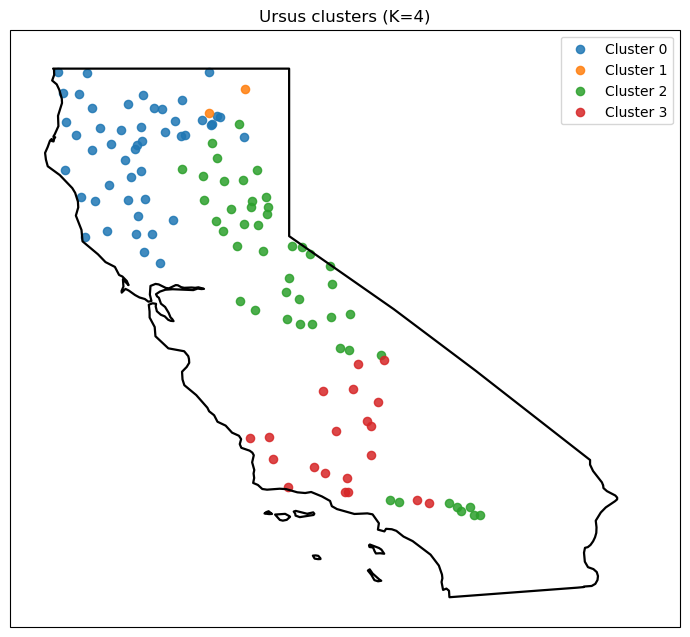

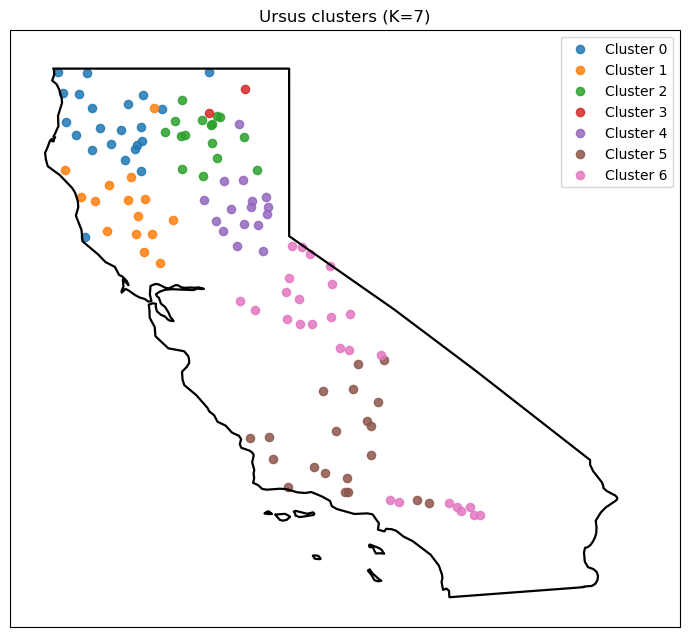

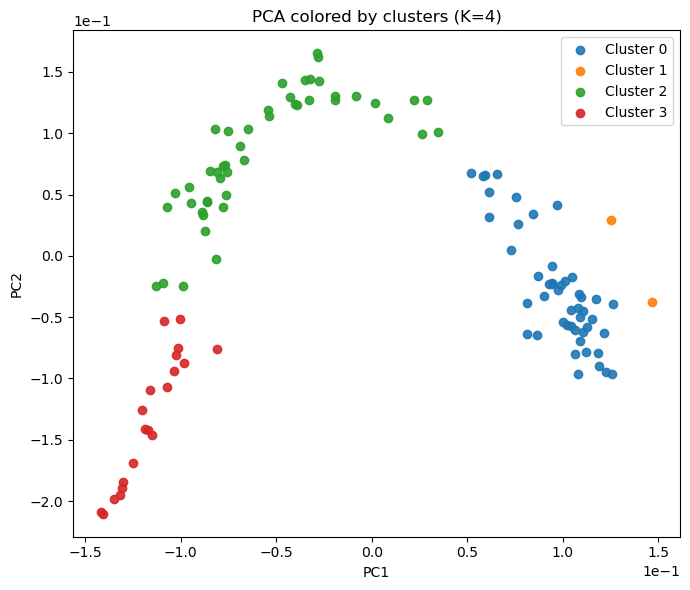

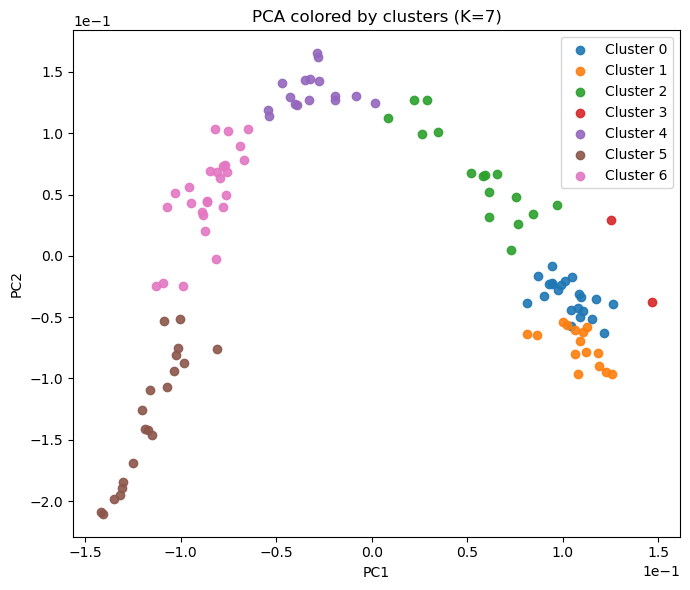

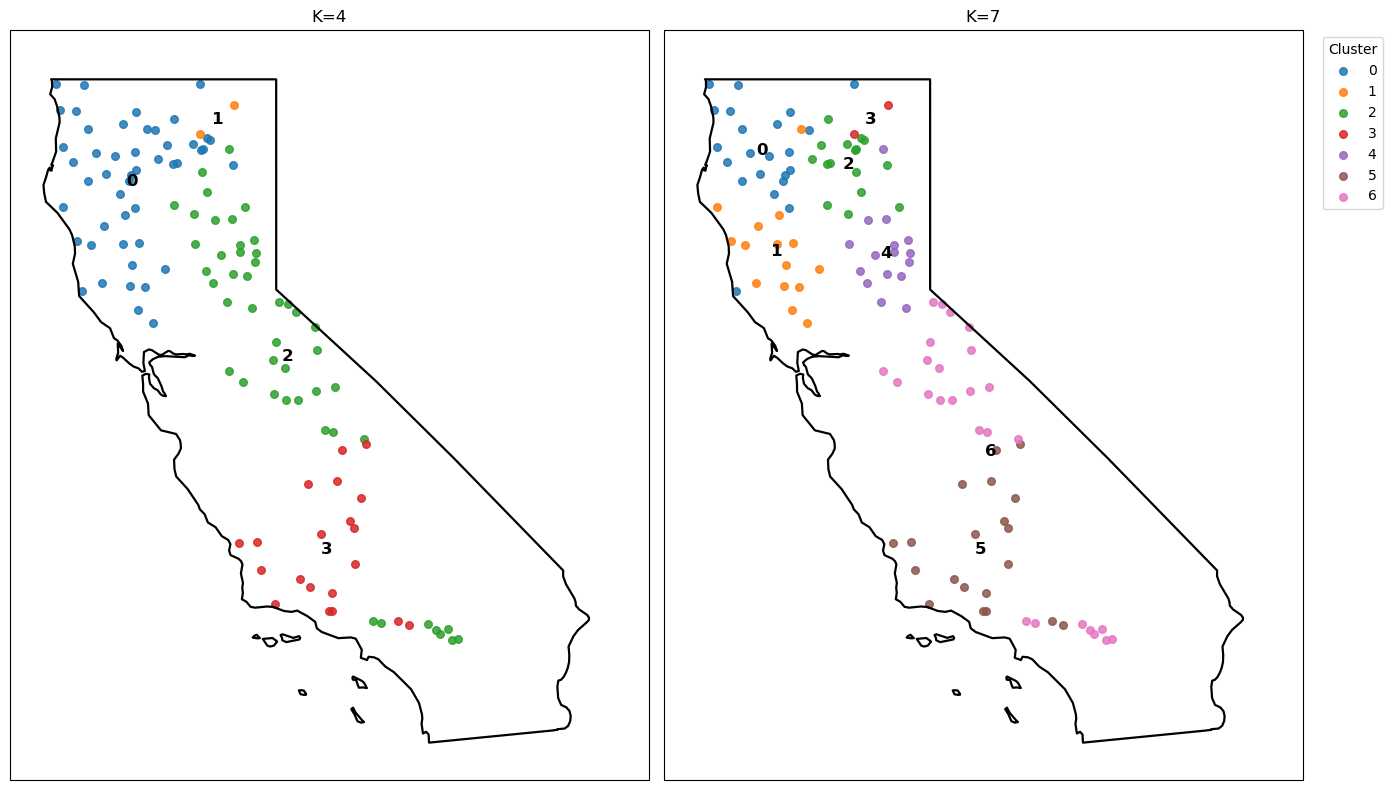

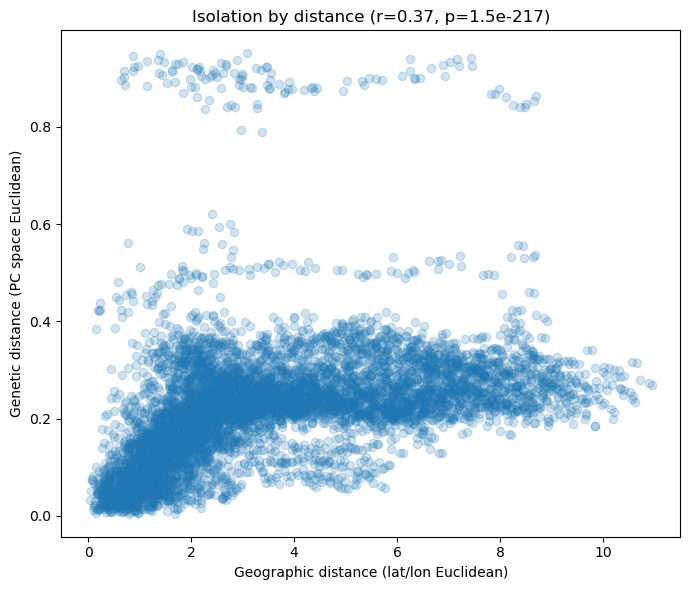

Isolation-by-distance: {'r': np.float64(0.36869360869985657), 'p': np.float64(1.5296235374689011e-217)}

Top PCA outliers by nearest-neighbor distance:
                  IID        lat         lon  nn_PC_dist
105  CCGPMC019b_B2631  41.636418 -120.785555    0.560093
58    CCGPMC010_B2002  41.213243 -121.437584    0.361320
81    CCGPMC010_B2432  41.159091 -121.296794    0.053860
76    CCGPMC010_B2273  41.062910 -122.046088    0.053860
1     CCGPMC010_B0541  41.040779 -123.998566    0.041579
115    Ursuamer_B2483  34.217180 -117.499228    0.040040
7     CCGPMC010_B0635  36.969942 -118.925264    0.038904
93   CCGPMC019b_B2296  41.431085 -121.911247    0.035955
111    Ursuamer_B2152  34.266861 -117.705434    0.033033
75    CCGPMC010_B2272  36.863936 -118.346716    0.033033

Done. Plots saved to: /Users/isabelmikheev/Desktop/Bioinformatics/plots


In [5]:
plot_map(df, labels4, f"Ursus clusters (K=4)")
plot_map(df, labels7, f"Ursus clusters (K=7)")


plot_pca_colored(df, labels4, "PCA colored by clusters (K=4)", os.path.join(OUTDIR, "pca_colored_K4.png"))
plot_pca_colored(df, labels7, "PCA colored by clusters (K=7)", os.path.join(OUTDIR, "pca_colored_K7.png"))

plot_two_maps(df, labels4, labels7)

plot_isolation_by_distance(df, pc_cols, os.path.join(OUTDIR, "isolation_by_distance.png"))

print_nn_outliers(df, pc_cols, top_n=10)

print("\nDone. Plots saved to:", OUTDIR)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

def relabel_by_mean_lon(df, labels):
    tmp = df.copy()
    tmp["cluster"] = labels
    order = tmp.groupby("cluster")["lon"].mean().sort_values().index.tolist()
    mapping = {old:new for new, old in enumerate(order)}
    return np.array([mapping[x] for x in labels])

pcs = df[pc_cols].to_numpy()
D = cdist(pcs, pcs)
np.fill_diagonal(D, np.inf)
df = df.copy()
df["nn_PC_dist"] = D.min(axis=1)

outliers = df.sort_values("nn_PC_dist", ascending=False).head(2)
outlier_ids = outliers["IID"].tolist()
print("Top outliers:", outliers[["IID","lat","lon","nn_PC_dist"]])

def labels_for_K(K):
    km = KMeans(n_clusters=K, n_init=50, random_state=1)
    lab = km.fit_predict(X)
    return relabel_by_mean_lon(df, lab)

lab4 = labels_for_K(4)
lab7 = labels_for_K(7)

df["K4"] = lab4
df["K7"] = lab7

print("\nOutliers with clusters:")
print(df[df["IID"].isin(outlier_ids)][["IID","lat","lon","nn_PC_dist","K4","K7"]])

Top outliers:                   IID        lat         lon  nn_PC_dist
105  CCGPMC019b_B2631  41.636418 -120.785555    0.560093
58    CCGPMC010_B2002  41.213243 -121.437584    0.361320

Outliers with clusters:
                  IID        lat         lon  nn_PC_dist  K4  K7
58    CCGPMC010_B2002  41.213243 -121.437584    0.361320   1   3
105  CCGPMC019b_B2631  41.636418 -120.785555    0.560093   1   3


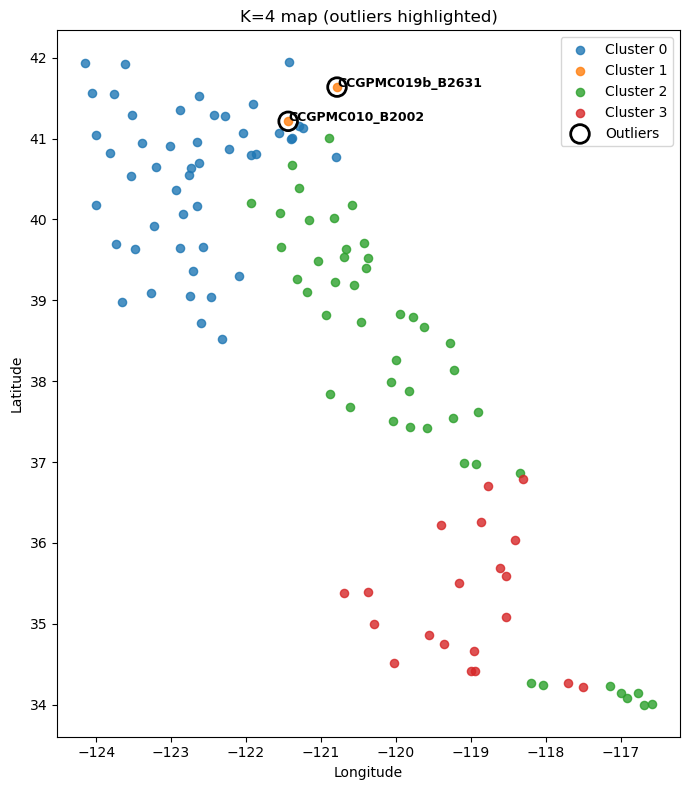

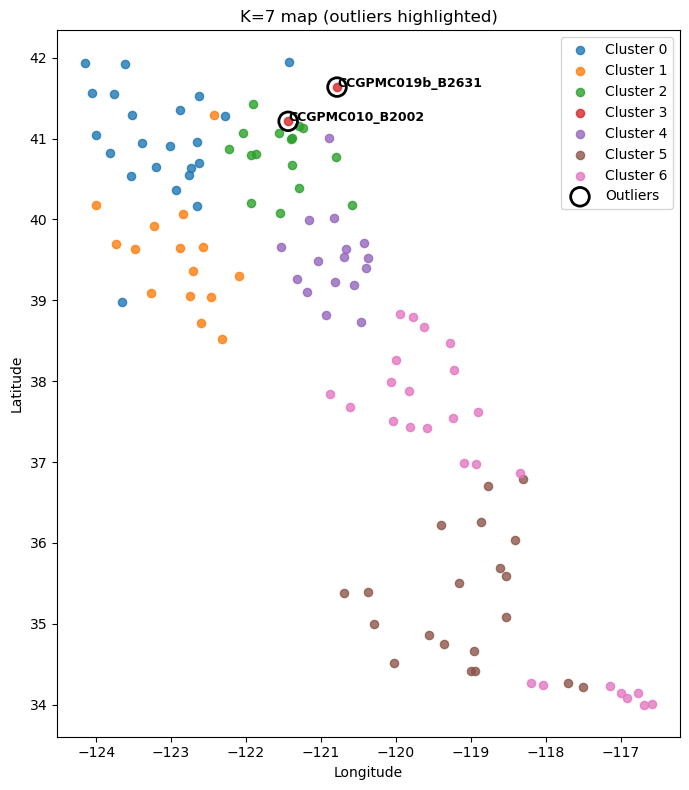

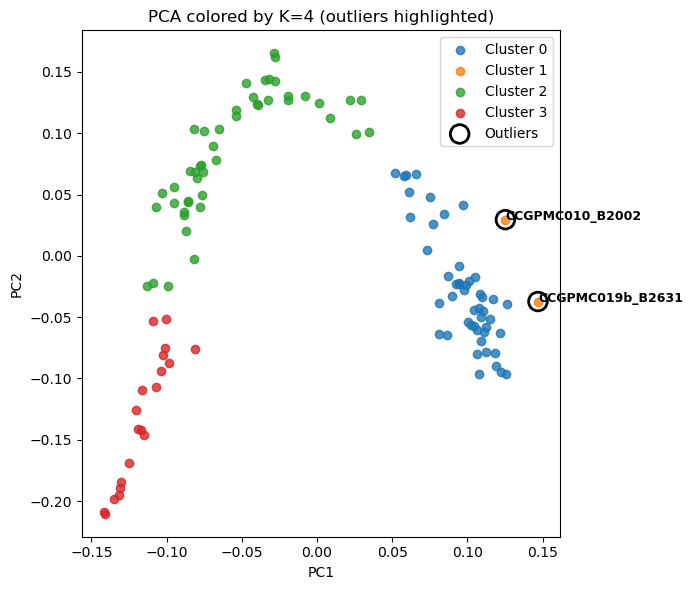

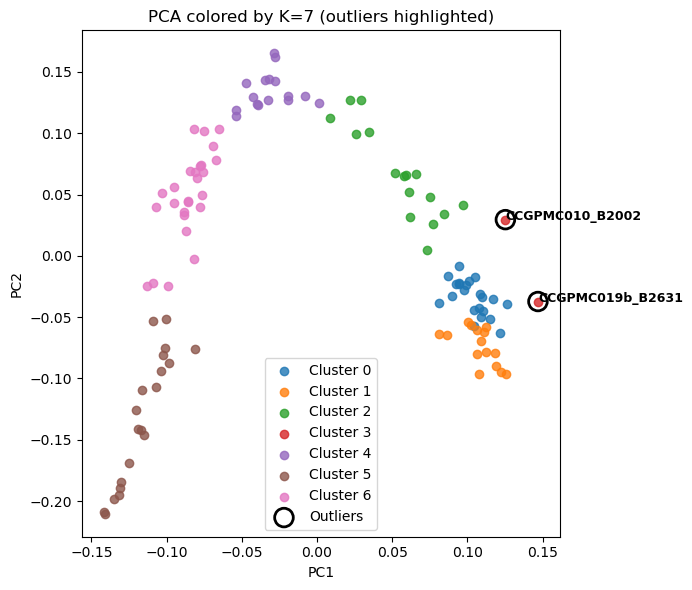

In [ ]:
import matplotlib.pyplot as plt

def plot_map_with_outliers(df, labels, title):
    plt.figure(figsize=(7,8))
    for cl in sorted(np.unique(labels)):
        sub = df[labels == cl]
        plt.scatter(sub["lon"], sub["lat"], s=35, alpha=0.8, label=f"Cluster {cl}")

    o = df[df["IID"].isin(outlier_ids)]
    plt.scatter(o["lon"], o["lat"], s=180, facecolors="none", edgecolors="black", linewidths=2, label="Outliers")
    for _, r in o.iterrows():
        plt.text(r["lon"], r["lat"], r["IID"], fontsize=9, fontweight="bold")

    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_pca_with_outliers(df, labels, title):
    plt.figure(figsize=(7,6))
    for cl in sorted(np.unique(labels)):
        sub = df[labels == cl]
        plt.scatter(sub["PC1"], sub["PC2"], alpha=0.8, label=f"Cluster {cl}")

    o = df[df["IID"].isin(outlier_ids)]
    plt.scatter(o["PC1"], o["PC2"], s=180, facecolors="none", edgecolors="black", linewidths=2, label="Outliers")
    for _, r in o.iterrows():
        plt.text(r["PC1"], r["PC2"], r["IID"], fontsize=9, fontweight="bold")

    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_map_with_outliers(df, lab4, "K=4 map (outliers highlighted)")
plot_map_with_outliers(df, lab7, "K=7 map (outliers highlighted)")
plot_pca_with_outliers(df, lab4, "PCA colored by K=4 (outliers highlighted)")
plot_pca_with_outliers(df, lab7, "PCA colored by K=7 (outliers highlighted)")

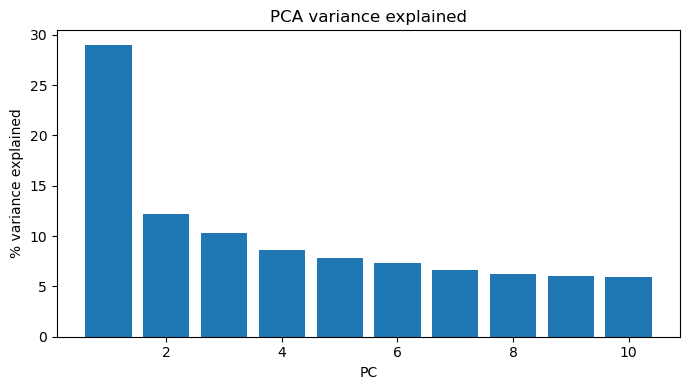

In [8]:
# PCA variance explained bar plot

import numpy as np, matplotlib.pyplot as plt

EIGENVAL = "/Users/isabelmikheev/Desktop/Bioinformatics/ursus_pca.eigenval"
eig = np.loadtxt(EIGENVAL)
pct = 100 * eig / eig.sum()

plt.figure(figsize=(7,4))
plt.bar(np.arange(1, len(pct)+1), pct)
plt.xlabel("PC")
plt.ylabel("% variance explained")
plt.title("PCA variance explained")
plt.tight_layout()
plt.show()

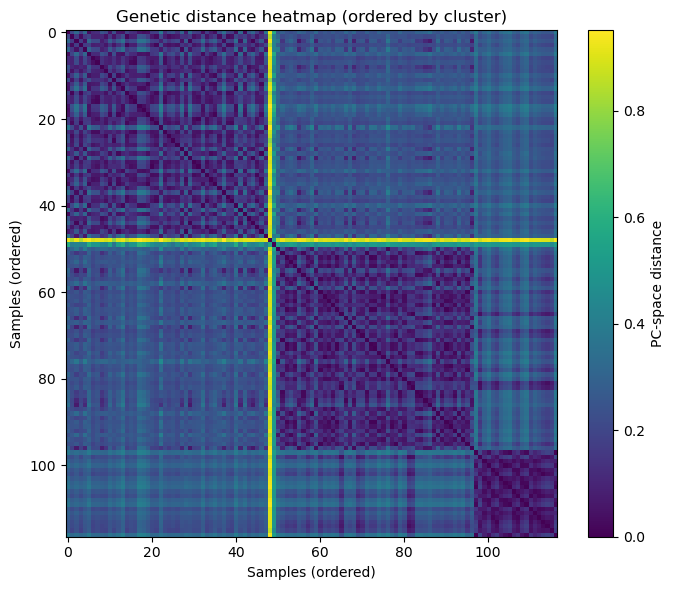

In [29]:
# Genetic distnce heatmap

import numpy as np, matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

labels = labels4
pcs = df[pc_cols].to_numpy()
D = squareform(pdist(pcs, metric="euclidean"))

order = np.argsort(labels)
D_ord = D[np.ix_(order, order)]

plt.figure(figsize=(7,6))
plt.imshow(D_ord, aspect="auto")
plt.colorbar(label="PC-space distance")
plt.title("Genetic distance heatmap (ordered by cluster)")
plt.xlabel("Samples (ordered)")
plt.ylabel("Samples (ordered)")
plt.tight_layout()
plt.show()

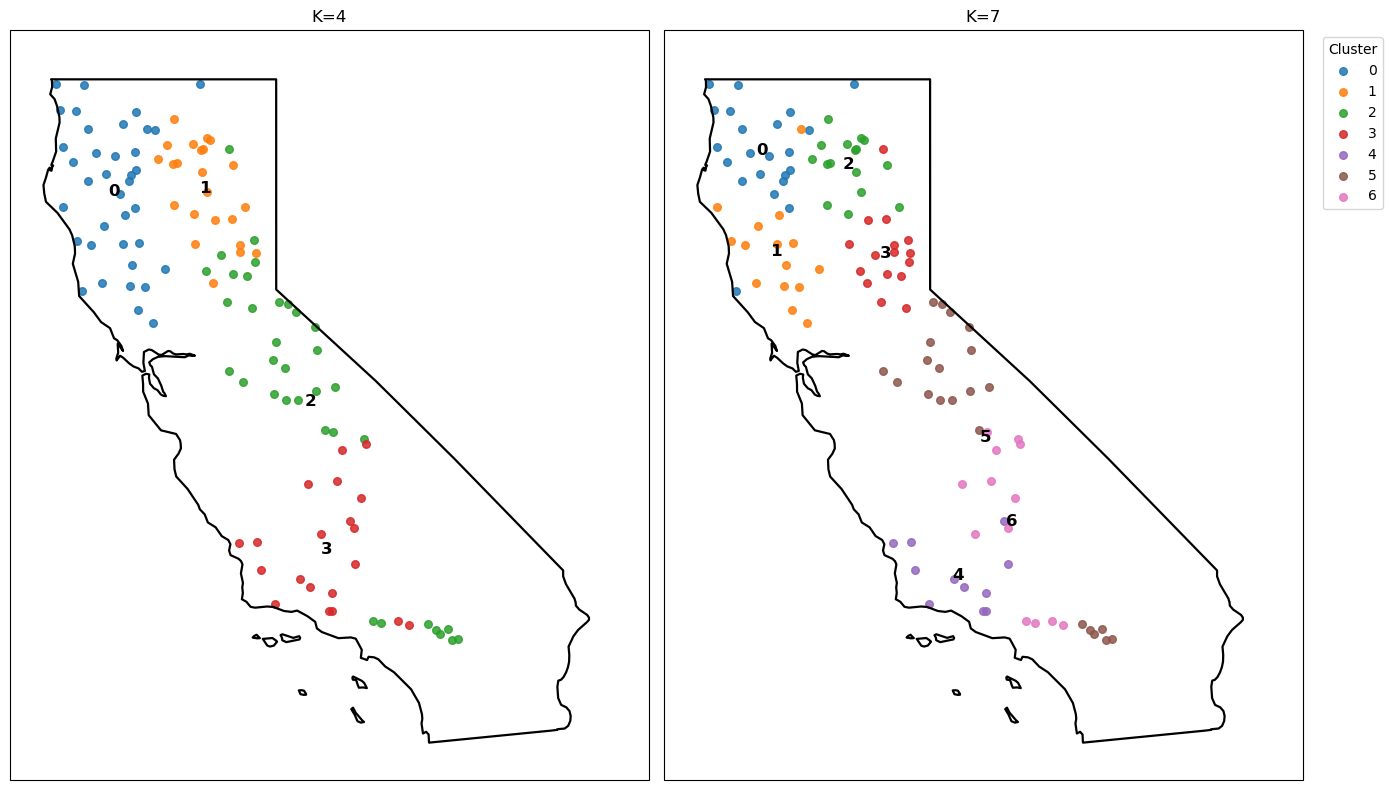

In [ ]:
# Cluster stability

from sklearn.cluster import KMeans
import numpy as np

outlier_ids = ["CCGPMC010_B2002", "CCGPMC019b_B2631"]

mask = ~df["IID"].isin(outlier_ids)
df_no = df.loc[mask].copy()
X_no = df_no[pc_cols].to_numpy()

def labels_for_K_on(dfX, K):
    km = KMeans(n_clusters=K, n_init=50, random_state=1)
    labs = km.fit_predict(dfX)

    tmp = df_no.copy()
    tmp["cluster"] = labs
    order = tmp.groupby("cluster")["lon"].mean().sort_values().index.tolist()
    mapping = {old:new for new, old in enumerate(order)}
    return np.array([mapping[x] for x in labs])

labels4_no = labels_for_K_on(X_no, 4)
labels7_no = labels_for_K_on(X_no, 7)

plot_two_maps(df_no, labels4_no, labels7_no)  

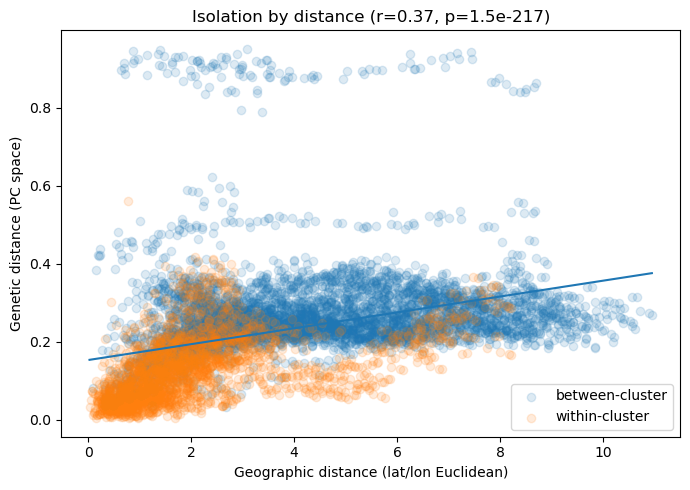

In [30]:
# Isolation by distance

import numpy as np, matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr

labels = labels4
pcs = df[pc_cols].to_numpy()
geo = df[["lat","lon"]].to_numpy()

genD = squareform(pdist(pcs, metric="euclidean"))
geoD = squareform(pdist(geo, metric="euclidean"))

iu = np.triu_indices_from(genD, k=1)
x = geoD[iu]
y = genD[iu]

same = (labels[iu[0]] == labels[iu[1]])

r, p = pearsonr(x, y)
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(7,5))
plt.scatter(x[~same], y[~same], alpha=0.15, label="between-cluster")
plt.scatter(x[same],  y[same],  alpha=0.15, label="within-cluster")
xx = np.linspace(x.min(), x.max(), 200)
plt.plot(xx, m*xx + b)
plt.xlabel("Geographic distance (lat/lon Euclidean)")
plt.ylabel("Genetic distance (PC space)")
plt.title(f"Isolation by distance (r={r:.2f}, p={p:.1e})")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
KIN_PATH = "/Users/isabelmikheev/Desktop/Bioinformatics/59-Ursus_king.kin"
kin = pd.read_csv(KIN_PATH, sep=r"\s+", engine="python")
kin["Kinship"] = pd.to_numeric(kin["Kinship"], errors="coerce")

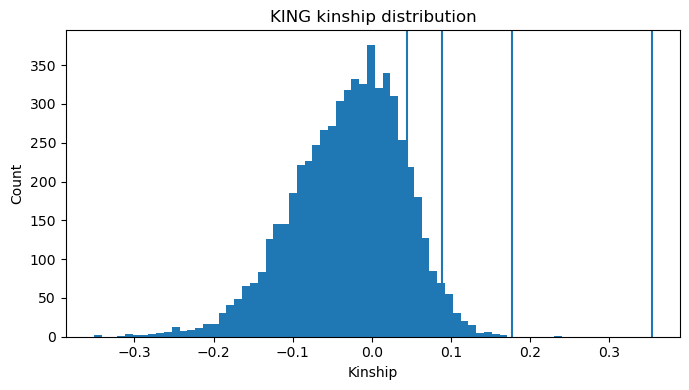

In [14]:
# KING kinship histogram

plt.figure(figsize=(7,4))
plt.hist(kin["Kinship"].dropna(), bins=60)
for t, lab in [(0.354,"dup/MZ"), (0.177,"1st"), (0.0884,"2nd"), (0.0442,"3rd")]:
    plt.axvline(t)
plt.title("KING kinship distribution")
plt.xlabel("Kinship")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

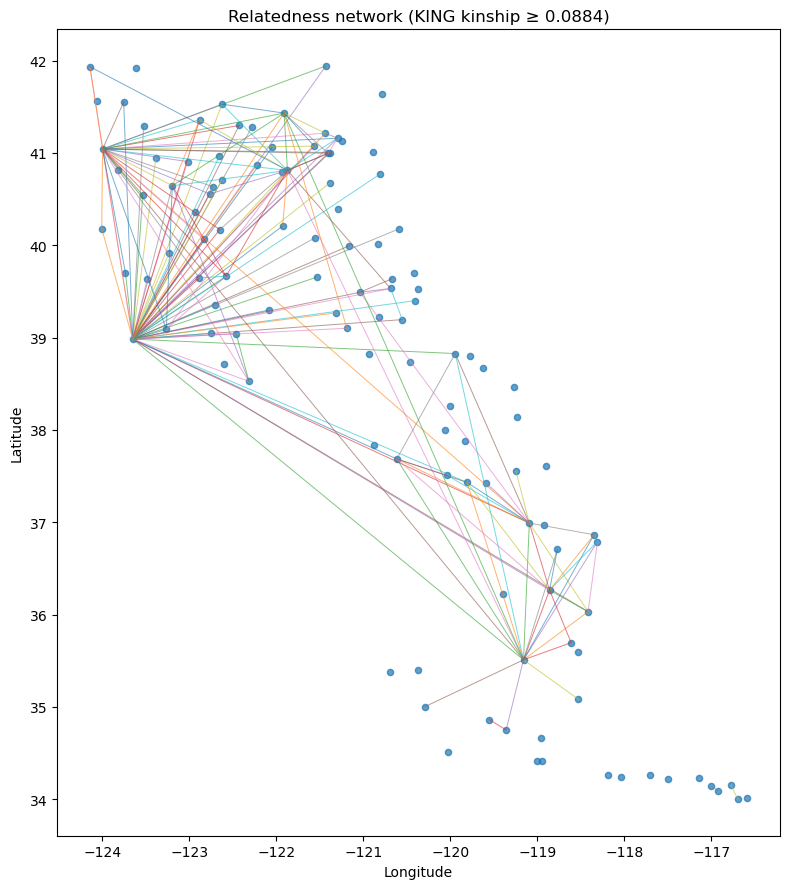

Edges drawn: 160


In [ ]:
# Relatedness network

import networkx as nx

THR = 0.0884 

edges = kin.loc[kin["Kinship"] >= THR, ["ID1","ID2","Kinship"]].dropna()
pos = dict(zip(df["IID"].astype(str), zip(df["lon"], df["lat"])))

G = nx.Graph()
for _, r in edges.iterrows():
    a, b = str(r["ID1"]), str(r["ID2"])
    if a in pos and b in pos:
        G.add_edge(a, b, w=float(r["Kinship"]))

plt.figure(figsize=(8,9))
plt.scatter(df["lon"], df["lat"], s=20, alpha=0.7)

for a, b in G.edges():
    x0, y0 = pos[a]
    x1, y1 = pos[b]
    plt.plot([x0,x1],[y0,y1], linewidth=0.7, alpha=0.6)

plt.title(f"Relatedness network (KING kinship ≥ {THR})")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

print("Edges drawn:", G.number_of_edges())

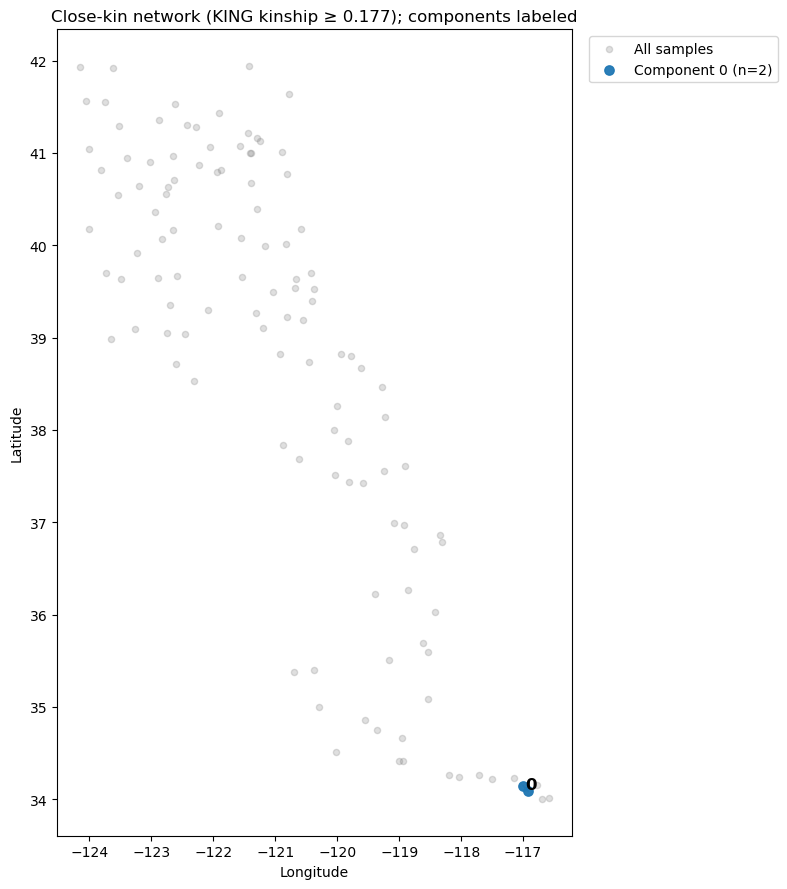

Edges: 1 Components with edges: 1


In [ ]:
import networkx as nx

THR = 0.177  

edges = kin.loc[kin["Kinship"] >= THR, ["ID1","ID2","Kinship"]].dropna().copy()
edges["ID1"] = edges["ID1"].astype(str)
edges["ID2"] = edges["ID2"].astype(str)

pos = dict(zip(df["IID"].astype(str), zip(df["lon"], df["lat"])))

G = nx.Graph()
G.add_nodes_from(pos.keys())
for _, r in edges.iterrows():
    a, b = r["ID1"], r["ID2"]
    if a in pos and b in pos:
        G.add_edge(a, b, w=float(r["Kinship"]))

comps = sorted(nx.connected_components(G), key=len, reverse=True)

plt.figure(figsize=(8,9))

plt.scatter(df["lon"], df["lat"], s=20, alpha=0.25, color="gray", label="All samples")

comp_id = 0
for comp in comps:
    if len(comp) < 2:
        continue
    nodes = list(comp)

    for a, b in G.subgraph(nodes).edges():
        x0, y0 = pos[a]
        x1, y1 = pos[b]
        plt.plot([x0, x1], [y0, y1], linewidth=1.2, alpha=0.8)

    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    plt.scatter(xs, ys, s=45, alpha=0.95, label=f"Component {comp_id} (n={len(nodes)})")

    cx, cy = np.mean(xs), np.mean(ys)
    plt.text(cx, cy, str(comp_id), fontsize=12, fontweight="bold")

    comp_id += 1

plt.title(f"Close-kin network (KING kinship ≥ {THR}); components labeled")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Edges:", G.number_of_edges(), "Components with edges:", comp_id)

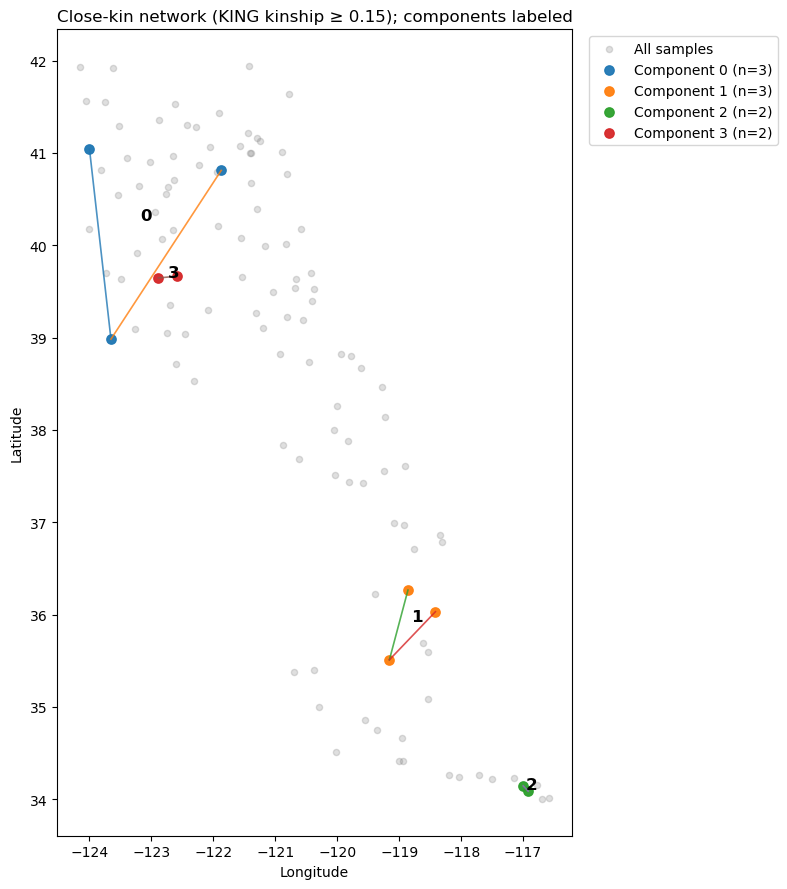

Edges: 6 Components with edges: 4


In [ ]:
import networkx as nx

THR = 0.15 

edges = kin.loc[kin["Kinship"] >= THR, ["ID1","ID2","Kinship"]].dropna().copy()
edges["ID1"] = edges["ID1"].astype(str)
edges["ID2"] = edges["ID2"].astype(str)

pos = dict(zip(df["IID"].astype(str), zip(df["lon"], df["lat"])))

G = nx.Graph()
G.add_nodes_from(pos.keys())
for _, r in edges.iterrows():
    a, b = r["ID1"], r["ID2"]
    if a in pos and b in pos:
        G.add_edge(a, b, w=float(r["Kinship"]))

comps = sorted(nx.connected_components(G), key=len, reverse=True)

plt.figure(figsize=(8,9))

plt.scatter(df["lon"], df["lat"], s=20, alpha=0.25, color="gray", label="All samples")

comp_id = 0
for comp in comps:
    if len(comp) < 2:
        continue
    nodes = list(comp)

    for a, b in G.subgraph(nodes).edges():
        x0, y0 = pos[a]
        x1, y1 = pos[b]
        plt.plot([x0, x1], [y0, y1], linewidth=1.2, alpha=0.8)

    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    plt.scatter(xs, ys, s=45, alpha=0.95, label=f"Component {comp_id} (n={len(nodes)})")

    cx, cy = np.mean(xs), np.mean(ys)
    plt.text(cx, cy, str(comp_id), fontsize=12, fontweight="bold")

    comp_id += 1

plt.title(f"Close-kin network (KING kinship ≥ {THR}); components labeled")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Edges:", G.number_of_edges(), "Components with edges:", comp_id)

In [ ]:
pos = dict(zip(df["IID"].astype(str), zip(df["lon"], df["lat"])))

def stats_for_thr(thr):
    edges = kin.loc[kin["Kinship"] >= thr, ["ID1","ID2"]].dropna()
    G = nx.Graph()

    for a,b in edges.to_numpy():
        a,b = str(a), str(b)
        if a in pos and b in pos:
            G.add_edge(a,b)
    comps = [c for c in nx.connected_components(G)]
    sizes = sorted([len(c) for c in comps], reverse=True)
    return G.number_of_edges(), len(sizes), (sizes[0] if sizes else 0)

for thr in [0.177, 0.15, 0.12, 0.10, 0.0884, 0.07, 0.0442]:
    e, ncomp, maxsz = stats_for_thr(thr)
    print(f"thr={thr:>6}: edges={e:>3}, components={ncomp:>3}, largest_comp={maxsz}")

thr= 0.177: edges=  1, components=  1, largest_comp=2
thr=  0.15: edges=  6, components=  4, largest_comp=3
thr=  0.12: edges= 36, components=  2, largest_comp=29
thr=   0.1: edges= 90, components=  2, largest_comp=56
thr=0.0884: edges=160, components=  3, largest_comp=73
thr=  0.07: edges=323, components=  1, largest_comp=93
thr=0.0442: edges=790, components=  1, largest_comp=109


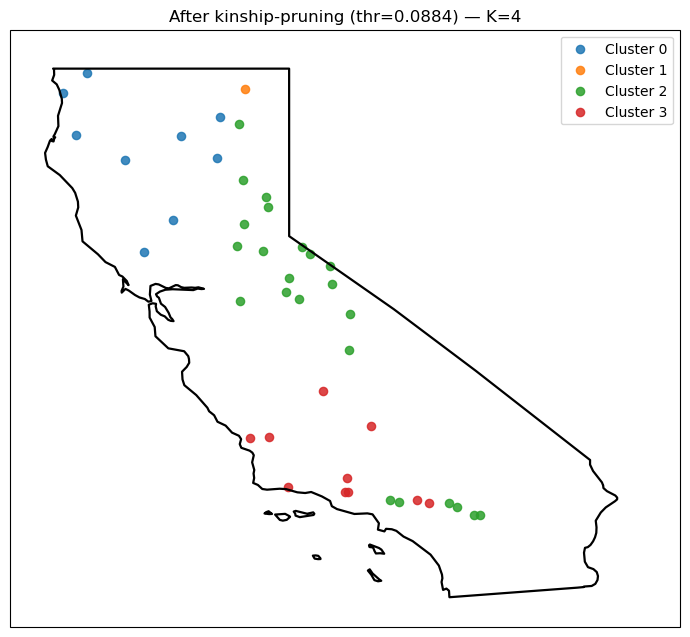

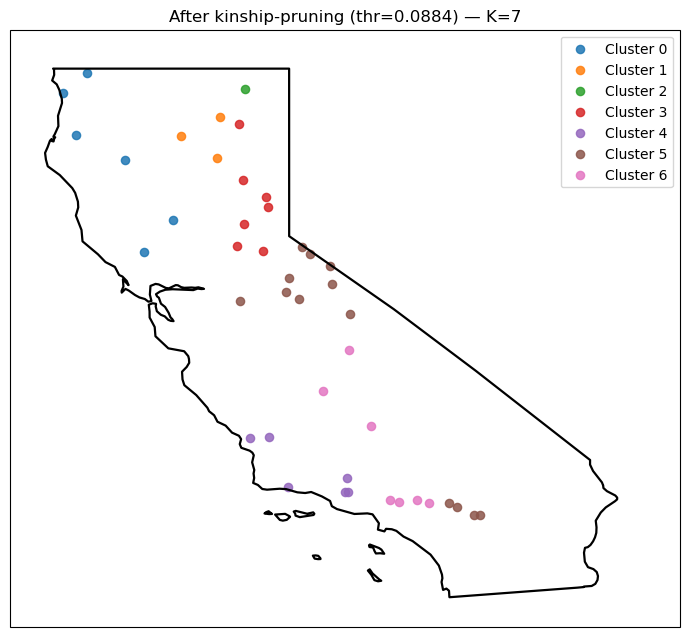

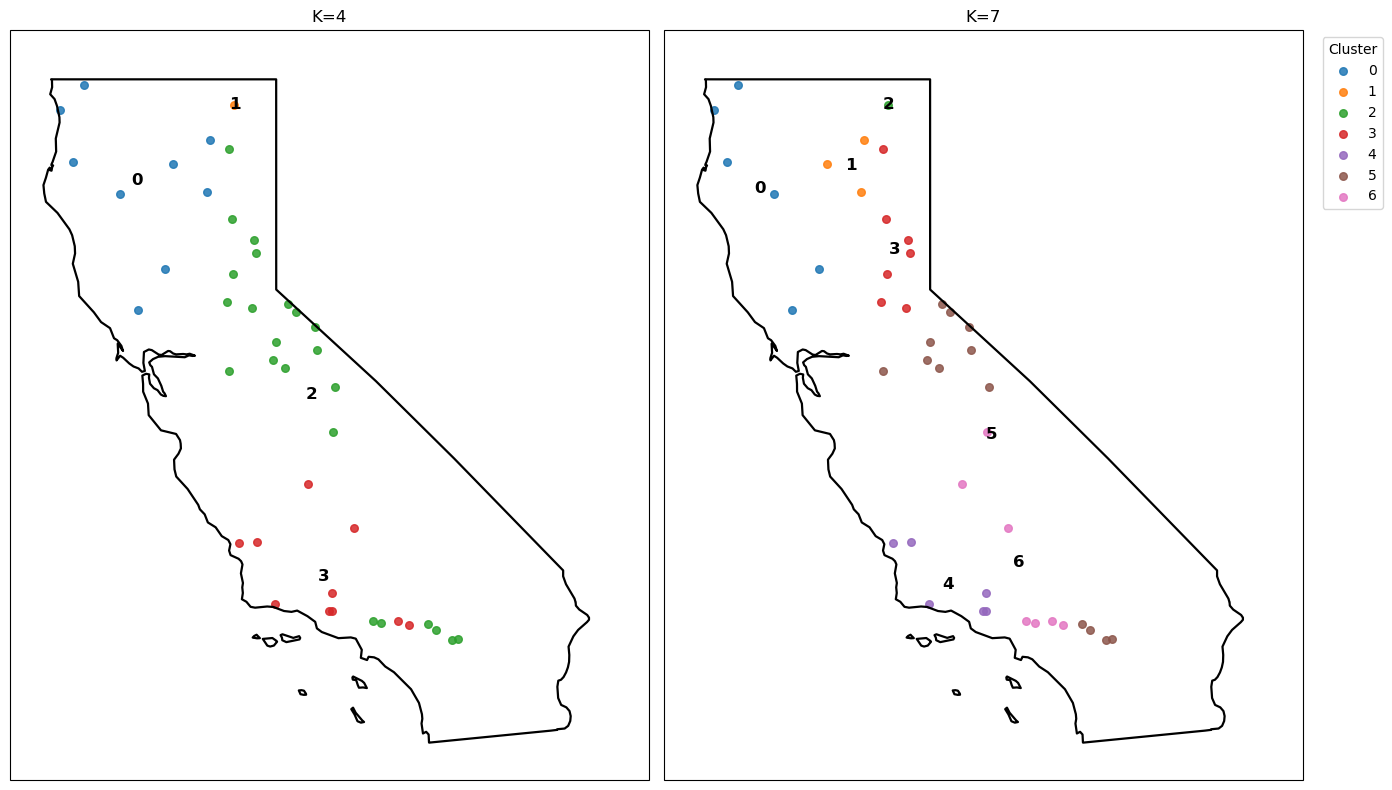

Original N: 117 Pruned N: 43


In [ ]:
# Kinship prune

from sklearn.cluster import KMeans
import numpy as np
import networkx as nx

THR = 0.0884 p

edges = kin.loc[kin["Kinship"] >= THR, ["ID1","ID2"]].dropna()
G = nx.Graph()
for _, r in edges.iterrows():
    G.add_edge(str(r["ID1"]), str(r["ID2"]))

all_ids = set(df["IID"].astype(str))
in_graph = set(G.nodes())

keep = set()
for comp in nx.connected_components(G):
    keep.add(sorted(comp)[0])
keep |= (all_ids - in_graph)

df_pruned = df[df["IID"].astype(str).isin(keep)].copy()
X_pruned = df_pruned[pc_cols].to_numpy()

def relabel_by_mean_lon_local(df_local, labels):
    tmp = df_local.copy()
    tmp["cluster"] = labels
    order = tmp.groupby("cluster")["lon"].mean().sort_values().index.tolist()
    mapping = {old:new for new, old in enumerate(order)}
    return np.array([mapping[x] for x in labels])

def labels_for_K(df_local, X_local, K):
    km = KMeans(n_clusters=K, n_init=50, random_state=1)
    labs = km.fit_predict(X_local)
    return relabel_by_mean_lon_local(df_local, labs)

labels4_p = labels_for_K(df_pruned, X_pruned, 4)
labels7_p = labels_for_K(df_pruned, X_pruned, 7)

plot_map(df_pruned, labels4_p, f"After kinship-pruning (thr={THR}) — K=4")
plot_map(df_pruned, labels7_p, f"After kinship-pruning (thr={THR}) — K=7")
plot_two_maps(df_pruned, labels4_p, labels7_p)

print("Original N:", len(df), "Pruned N:", len(df_pruned))

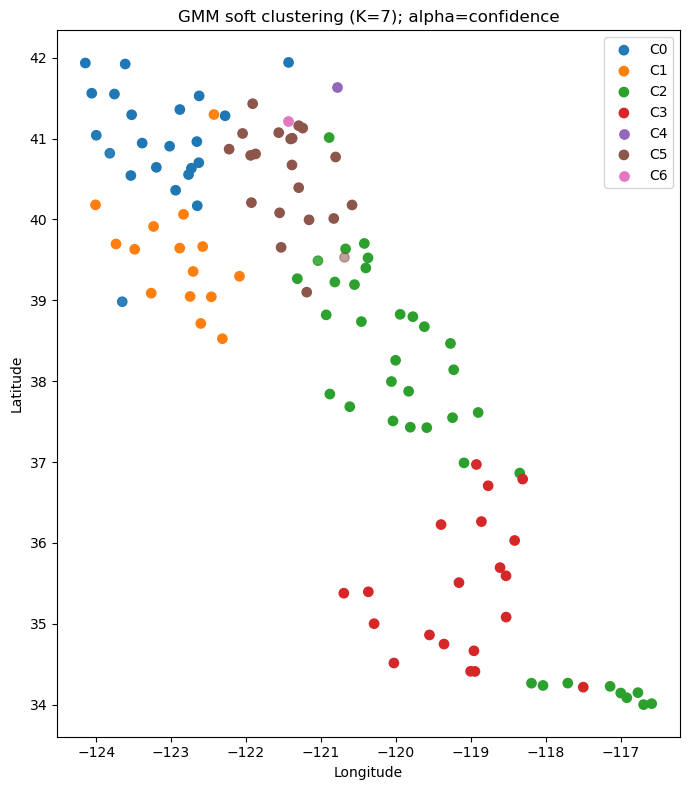

In [ ]:
# soft clustering

from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

K = 7
Xpcs = df[pc_cols].to_numpy()
gmm = GaussianMixture(n_components=K, covariance_type="full", random_state=1)
probs = gmm.fit_predict(Xpcs), gmm.predict_proba(Xpcs)

labels_gmm = probs[0]
P = probs[1]            
df_gmm = df.copy()
df_gmm["gmm_cluster"] = labels_gmm
df_gmm["max_prob"] = P.max(axis=1)

plt.figure(figsize=(7,8))
for cl in range(K):
    sub = df_gmm[df_gmm["gmm_cluster"] == cl]
    plt.scatter(sub["lon"], sub["lat"], alpha=sub["max_prob"], s=45, label=f"C{cl}")
plt.title(f"GMM soft clustering (K={K}); alpha=confidence")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# cluster separation

import numpy as np
import pandas as pd

labels = labels7
Xpcs = df[pc_cols].to_numpy()

centroids = pd.DataFrame(Xpcs).groupby(labels).mean().to_numpy()
within = []
for k in np.unique(labels):
    pts = Xpcs[labels == k]
    within.append(np.mean(np.linalg.norm(pts - pts.mean(axis=0), axis=1)))
within = np.array(within)

from scipy.spatial.distance import pdist, squareform
Cdist = squareform(pdist(centroids))

print("Mean within-cluster spread by cluster:", within)
print("Centroid distance matrix:\n", np.round(Cdist, 3))
print("Separation ratio (mean centroid dist / mean within spread):",
      Cdist[np.triu_indices_from(Cdist,1)].mean() / within.mean())

Mean within-cluster spread by cluster: [0.04433434 0.03892096 0.05319948 0.28004663 0.03762395 0.06130645
 0.0533034 ]
Centroid distance matrix:
 [[0.    0.15  0.17  0.627 0.216 0.246 0.228]
 [0.15  0.    0.303 0.704 0.289 0.304 0.245]
 [0.17  0.303 0.    0.66  0.165 0.275 0.266]
 [0.627 0.704 0.66  0.    0.675 0.678 0.656]
 [0.216 0.289 0.165 0.675 0.    0.284 0.145]
 [0.246 0.304 0.275 0.678 0.284 0.    0.234]
 [0.228 0.245 0.266 0.656 0.145 0.234 0.   ]]
Separation ratio (mean centroid dist / mean within spread): 4.407768570525757


In [ ]:
# within vs. between

import pandas as pd, numpy as np

lab = labels7
id_to_lab = dict(zip(df["IID"].astype(str), lab))

k = kin.copy()
k["ID1"] = k["ID1"].astype(str); k["ID2"] = k["ID2"].astype(str)
k = k[k["ID1"].isin(id_to_lab) & k["ID2"].isin(id_to_lab)].copy()
k["same_cluster"] = k["ID1"].map(id_to_lab) == k["ID2"].map(id_to_lab)

print("Mean kinship within clusters:", k.loc[k["same_cluster"], "Kinship"].mean())
print("Mean kinship between clusters:", k.loc[~k["same_cluster"], "Kinship"].mean())
print("Median within:", k.loc[k["same_cluster"], "Kinship"].median(),
      "Median between:", k.loc[~k["same_cluster"], "Kinship"].median())

Mean kinship within clusters: 0.01779695378151261
Mean kinship between clusters: -0.03878654959090002
Median within: 0.0245 Median between: -0.032


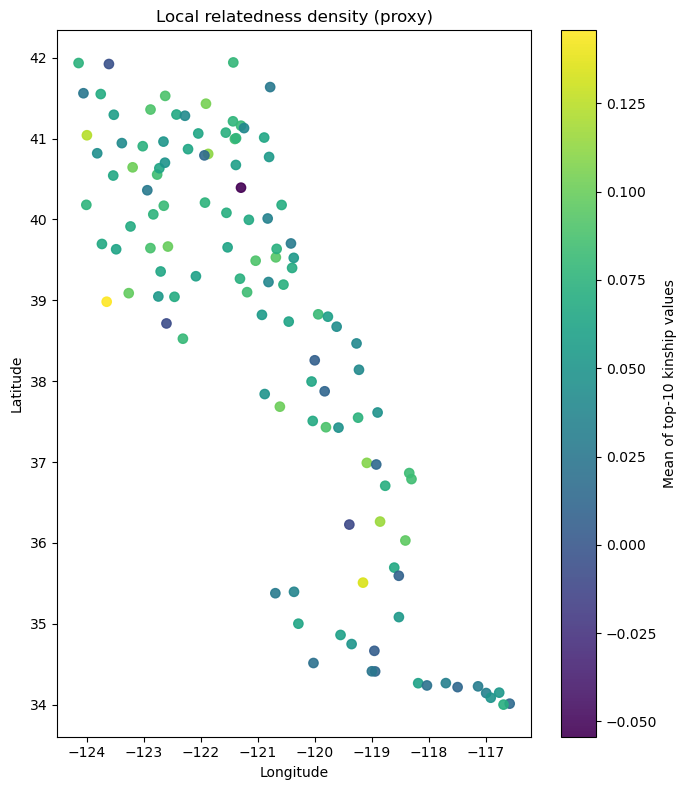

In [ ]:
# local diversity proxy map

import numpy as np

id_list = df["IID"].astype(str).tolist()
id_to_i = {s:i for i,s in enumerate(id_list)}
Kmat = np.zeros((len(id_list), len(id_list)), float)

k2 = kin[kin["ID1"].astype(str).isin(id_to_i) & kin["ID2"].astype(str).isin(id_to_i)].copy()
for _, r in k2.iterrows():
    i = id_to_i[str(r["ID1"])]; j = id_to_i[str(r["ID2"])]
    Kmat[i,j] = r["Kinship"]; Kmat[j,i] = r["Kinship"]

np.fill_diagonal(Kmat, -np.inf)
top10 = np.sort(Kmat, axis=1)[:, -10:]
local_score = np.mean(top10, axis=1)

tmp = df.copy()
tmp["local_kinship"] = local_score

import matplotlib.pyplot as plt
plt.figure(figsize=(7,8))
plt.scatter(tmp["lon"], tmp["lat"], c=tmp["local_kinship"], s=45, alpha=0.9)
plt.colorbar(label="Mean of top-10 kinship values")
plt.title("Local relatedness density (proxy)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [ ]:
# barrier hypothesis

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
import statsmodels.api as sm

pcs = df[pc_cols].to_numpy()
geo = df[["lat","lon"]].to_numpy()
genD = squareform(pdist(pcs))
geoD = squareform(pdist(geo))

# Example barrier: Central Valley-ish vertical line lon = -121.5
side = (df["lon"].to_numpy() > -121.5).astype(int)
B = (side[:,None] != side[None,:]).astype(int)

iu = np.triu_indices_from(genD, 1)
y = genD[iu]
Xreg = np.column_stack([geoD[iu], B[iu]])
Xreg = sm.add_constant(Xreg)

model = sm.OLS(y, Xreg).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     589.2
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          1.15e-236
Time:                        17:10:34   Log-Likelihood:                 4744.8
No. Observations:                6786   AIC:                            -9484.
Df Residuals:                    6783   BIC:                            -9463.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1480      0.003     53.804      0.0

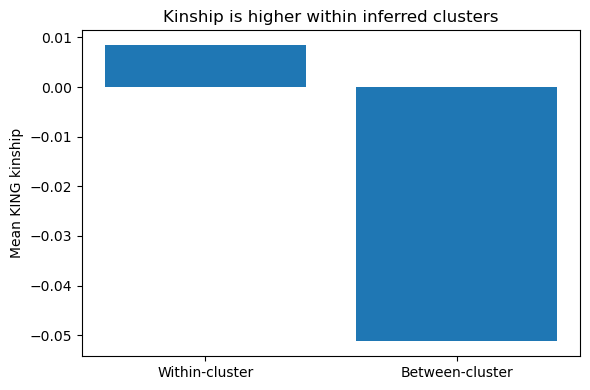

Within mean/median: 0.008446741154562383 0.0152
Between mean/median: -0.05126089121887287 -0.0474
N within: 2148 N between: 3815


In [22]:
# kinship within vs. between clusters

labels = labels4 
id_to_lab = dict(zip(df["IID"].astype(str), labels))

k = kin.copy()
k["ID1"] = k["ID1"].astype(str)
k["ID2"] = k["ID2"].astype(str)
k = k[k["ID1"].isin(id_to_lab) & k["ID2"].isin(id_to_lab)].copy()

k["same_cluster"] = (k["ID1"].map(id_to_lab) == k["ID2"].map(id_to_lab))
within = k.loc[k["same_cluster"], "Kinship"].dropna().to_numpy()
between = k.loc[~k["same_cluster"], "Kinship"].dropna().to_numpy()

means = [within.mean(), between.mean()]
meds  = [np.median(within), np.median(between)]

plt.figure(figsize=(6,4))
plt.bar(["Within-cluster", "Between-cluster"], means)
plt.ylabel("Mean KING kinship")
plt.title("Kinship is higher within inferred clusters")
plt.tight_layout()
plt.show()

print("Within mean/median:", within.mean(), np.median(within))
print("Between mean/median:", between.mean(), np.median(between))
print("N within:", len(within), "N between:", len(between))

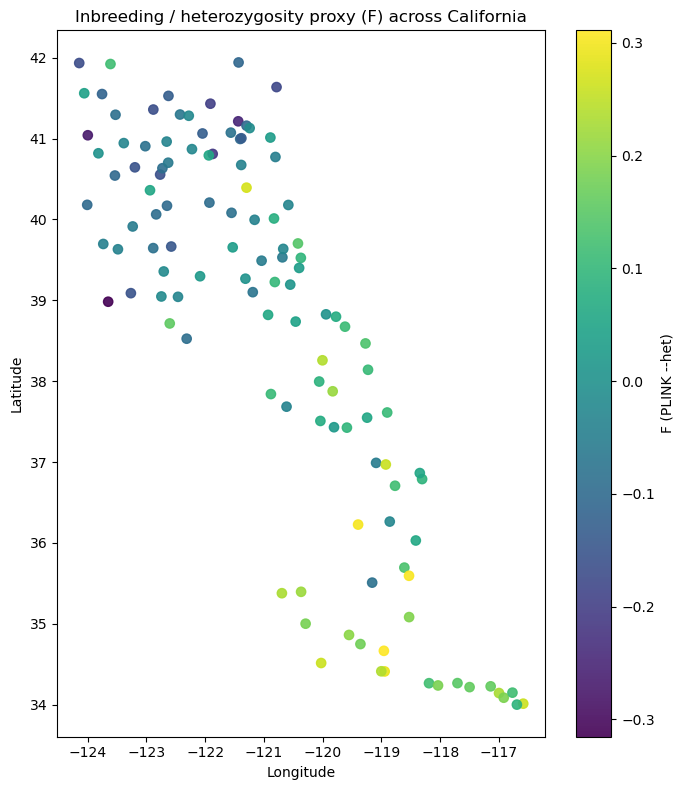

In [ ]:
# map of F

HET_PATH = "/Users/isabelmikheev/Desktop/Bioinformatics/plots/qc.het" 
het = pd.read_csv(HET_PATH, sep=r"\s+")
if "#FID" in het.columns and "FID" not in het.columns:
    het = het.rename(columns={"#FID":"FID"})

tmp = df.merge(het[["IID","F"]], on="IID", how="left")

plt.figure(figsize=(7,8))
plt.scatter(tmp["lon"], tmp["lat"], c=tmp["F"], s=45, alpha=0.9)
plt.colorbar(label="F (PLINK --het)")
plt.title("Inbreeding / heterozygosity proxy (F) across California")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

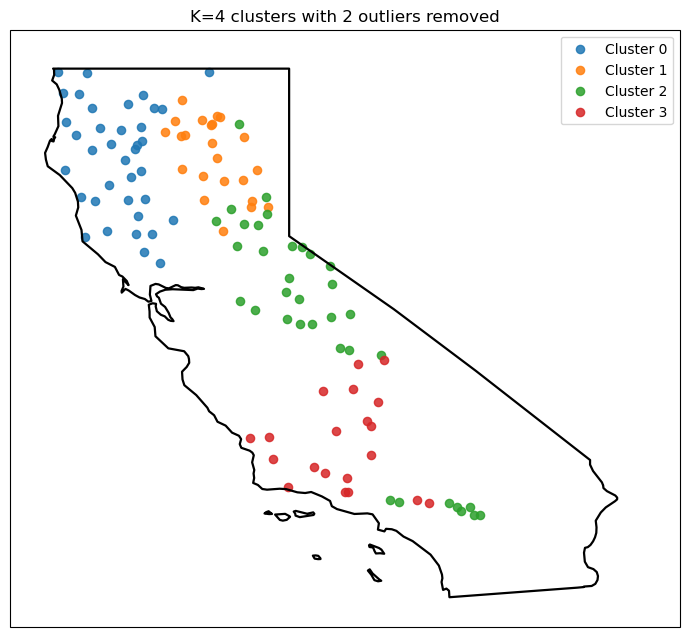

Original N: 117 After removing outliers: 115


In [ ]:
# outliers removed

import numpy as np
from sklearn.cluster import KMeans

outlier_ids = ["CCGPMC010_B2002", "CCGPMC019b_B2631"] 

df_no = df[~df["IID"].isin(outlier_ids)].copy()
X_no = df_no[pc_cols].to_numpy()

def relabel_by_mean_lon_local(df_local, labels):
    tmp = df_local.copy()
    tmp["cluster"] = labels
    order = tmp.groupby("cluster")["lon"].mean().sort_values().index.tolist()
    mapping = {old:new for new, old in enumerate(order)}
    return np.array([mapping[x] for x in labels])

km = KMeans(n_clusters=4, n_init=50, random_state=1)
labels4_no = relabel_by_mean_lon_local(df_no, km.fit_predict(X_no))

plot_map(df_no, labels4_no, "K=4 clusters with 2 outliers removed")
print("Original N:", len(df), "After removing outliers:", len(df_no))